# 👹 AN2DL Challenge 2: The Grumpy Doctogres Challenge

## Notebook 02: Exploratory Data Analysis (EDA)

This notebook:
- Loads the training and test datasets
- Explores the data distribution
- Visualizes some samples


### Setup

This section sets up the environment by importing necessary libraries

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from internal.persistence_manager import PersistenceManager

data = PersistenceManager.load_dataset()
train_df = data.train_df
test_df = data.test_df

Arrays and scalers loaded successfully from: /home/andre/university/AN2DL-Challenge-2/notebooks/processed/dataset.joblib


### Exploratory Data Analysis

This section performs exploratory data analysis (EDA) on the training dataset. It examines label distributions, checks for missing masks, computes image sizes, mask pixel counts, and bounding box areas. Finally, it visualizes a random sample from the dataset.

#### Label Distribution

This part analyzes the distribution of labels in the training dataset. The results show that the classes are relatively balanced, with 'Luminal B' being the most frequent and 'Triple negative' the least.

In [2]:
train_df['label'].value_counts()

label
Luminal B          445
Luminal A          414
HER2(+)            397
Triple negative    156
Name: count, dtype: int64

In [3]:
class_names = data.label2idx.keys()
for class_name in class_names:
    print(f"Descriptive statistics for class: {class_name}")
    print(train_df[train_df['label'] == class_name].describe())
    print("\n")

Descriptive statistics for class: Luminal B
             width       height    mask_pixels     bbox_area  label_idx
count   445.000000   445.000000     445.000000  4.450000e+02      445.0
mean   1277.460674  1311.056180   36448.438202  3.943581e+05        0.0
std     459.251718   475.359768   42508.710692  2.609501e+05        0.0
min    1024.000000  1024.000000    1980.000000  1.251200e+04        0.0
25%    1024.000000  1024.000000   11329.000000  1.964160e+05        0.0
50%    1024.000000  1065.000000   19639.000000  3.610880e+05        0.0
75%    1386.000000  1443.000000   42804.000000  5.504400e+05        0.0
max    3916.000000  4233.000000  262679.000000  1.662888e+06        0.0


Descriptive statistics for class: Luminal A
             width       height    mask_pixels     bbox_area  label_idx
count   414.000000   414.000000     414.000000  4.140000e+02      414.0
mean   1246.021739  1342.995169   32602.840580  3.777162e+05        1.0
std     438.276585   487.922482   42398.542893

In [4]:
train_df['label'].value_counts(normalize=True)

label
Luminal B          0.315156
Luminal A          0.293201
HER2(+)            0.281161
Triple negative    0.110482
Name: proportion, dtype: float64

#### Missing Masks

This part checks for missing masks in the training dataset. It identifies how many samples lack corresponding mask images.

The output indicates that there are no missing masks in the training dataset (1412 samples have masks, 0 do not).

In [5]:
train_df['mask_missing'] = train_df['mask_path'].isnull()
train_df['mask_missing'].value_counts()

mask_missing
False    1412
Name: count, dtype: int64

#### Visualize Sample

Just to get a feel of the data, this part visualizes a random sample from the training dataset, displaying both the image and its corresponding mask side by side.

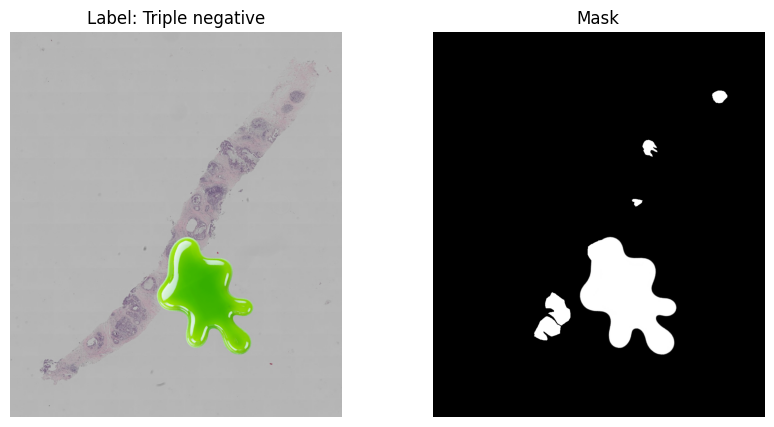

In [6]:
def show_sample(idx: int | None = None):
    if idx is None:
        idx = random.randint(0, len(train_df)-1)

    _row: pd.Series = train_df.iloc[idx]

    _img: np.ndarray = np.array(Image.open(_row["image_path"]))
    _mask: np.ndarray = np.array(Image.open(_row["mask_path"]))

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title(f"Label: {_row['label']}")
    plt.imshow(_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(_mask, cmap="gray")
    plt.axis("off")

    plt.show()

show_sample()

### Descriptive Statistics

This part provides descriptive statistics for the newly added columns in the training DataFrame, giving insights into the distribution of image dimensions, mask pixel counts, and bounding box areas.

#### Image Dimensions

The statistics indicate that the images vary significantly in size, with widths ranging from 1024 to 3970 pixels and heights from 1024 to 4233 pixels. The mean dimensions are approximately 1252x1341 pixels. The standard deviation values suggest a wide spread in image sizes. Additionally, the number of mask pixels and bounding box areas also show considerable variation, reflecting the diversity in the dataset.

In [7]:
train_df[['width','height']].describe()

,width,height
count,1412.000000,1412.000000
mean,1252.313031,1341.359065
std,446.147652,509.641453
min,1024.000000,1024.000000
25%,1024.000000,1024.000000
50%,1024.000000,1097.500000
75%,1294.000000,1468.250000
max,3970.000000,4233.000000


#### Mask Pixels

The statistics for `mask_pixels` show a wide range in the number of pixels covered by the masks, with a mean of approximately 34,220 pixels and a maximum of 355,190 pixels. This indicates significant variability in the size of the regions of interest across different samples. Additionally, the standard deviation is quite high, suggesting that some masks are much larger than others.

Finally, the quartile values indicate that 25% of the samples have masks with fewer than 10,401 pixels, while 75% have masks with fewer than 38,725 pixels, highlighting the skewed distribution of mask sizes in the dataset.


In [8]:
train_df['mask_pixels'].describe()

count      1412.000000
mean      34219.893768
std       42038.650096
min        1727.000000
25%       10401.500000
50%       19104.500000
75%       38725.000000
max      355190.000000
Name: mask_pixels, dtype: float64

#### Bounding Box Area

The statistics for `bbox_area` indicate a wide range of bounding box sizes around the masks, with a mean area of approximately 386,583 square pixels and a maximum area of 1,662,888 square pixels. This suggests significant variability in the size of the regions of interest across different samples. The standard deviation is also quite high, indicating that some bounding boxes are much larger than others. Additionally, the quartile values show that 25% of the samples have bounding box areas smaller than 191,561 square pixels, while 75% have areas smaller than 542,629 square pixels, highlighting the skewed distribution of bounding box sizes in the dataset.

Finally, the minimum bounding box area is 12,483 square pixels, indicating that even the smallest regions of interest are relatively substantial.

In [9]:
train_df['bbox_area'].describe()

count    1.412000e+03
mean     3.865837e+05
std      2.579475e+05
min      1.248300e+04
25%      1.915610e+05
50%      3.438030e+05
75%      5.426298e+05
max      1.662888e+06
Name: bbox_area, dtype: float64